# Setting up a relative binding free energy network

 This notebook demonstrates the **setup stage** of a Free Energy Perturbation (FEP) workflow using the [OpenFE](https://openfreeenergy.org) toolkit.  

Specifically:
- Select two ligands from a TYK2 benchmark set (loaded from SDF).
- Define chemical components for the protein, ligands, and solvent.
- Generate atom mappings between ligands using LoMap.
- Build bound (complex) and unbound (solvent) chemical systems.
- Specify a relative hybrid topology protocol and create `Transformation` objects.
- Serialize these transformations to JSON for later execution.

**Why this matters:**  
FEP/RBFE methods allow us to rigorously compute relative binding free energies between closely related ligands. This is useful in drug discovery pipelines where accurate ranking of compound series is critical.

**Limitations of this notebook:**  
- This notebook covers **setup only**. Simulation execution (sampling at multiple λ windows), free energy estimation (MBAR/BAR), and convergence analysis are handled in a separate script.  
- Protocol settings here use OpenFE defaults. In production, one should explicitly specify λ schedules, equilibration/production lengths, PME and softcore parameters, and random seeds.  
- Input preparation assumes ligands have consistent protonation/tautomeric states and charges.

**Next steps (not covered here):**  
- Run MD simulations for each alchemical intermediate on HPC/GPU resources.  
- Perform free energy analysis with MBAR.  
- Validate convergence by monitoring ΔG estimates vs. sampling length and across independent replicas.  


# Free Energy Perturbation and Thermodynamic Integration

**Why use FEP?**  
Free Energy Perturbation is a rigorous statistical mechanics method to compute the relative binding free energy $\Delta \Delta G$ between two ligands or between different states of a molecular system. In drug discovery, it helps predict how chemical modifications affect binding affinity, enabling more accurate prioritization of compounds than simpler scoring functions or docking approaches. FEP is particularly useful when evaluating small structural changes (substituents, scaffold hops, charge changes) where other methods may fail.

**How does FEP work?**  
FEP relies on simulating two molecular states (e.g., ligand A bound to a protein vs. ligand B bound to the protein) and computing the free energy difference via *alchemical transformations*. This is achieved by gradually “morphing” one molecule into another using a coupling parameter (λ) in molecular dynamics simulations $$U(\lambda) = (1-\lambda)U_A + \lambda U_B, 0 \leq \lambda \leq 1 $$. Simulation are run at each lambda step, and then integrated over these intermediate states using **MBAR** to remove the bias, the relative free energy difference ΔΔG can be obtained. A so called *FEP campaign* involves exploring all pairs of ligands that are available.

**In practice:**  
1. Define the two molecular states (ligand A → ligand B).  
2. Set up alchemical intermediates along the λ coordinate. This requires a mapping between atoms in A to atoms in B, it is a smooth mathematical transformation, not a physical one
3. Run molecular dynamics (or Monte Carlo) simulations for each λ state.  
4. Collect energy statistics and compute ΔG via exponential averaging (Zwanzig relation) or free energy estimators (BAR/MBAR).  
5. Compare computed ΔΔG to experimental binding data when available.  

This notebook demonstrates how to set up and analyze such calculations in practice.

In [1]:
import matplotlib
%matplotlib inline

import numpy as np
import openfe

In [2]:
import os

## Loading the players: here we just focus on a single transformation A --> B between TYK2 ligands

In [3]:
from openff.toolkit import Molecule
from openfe import SmallMoleculeComponent, SolventComponent, ProteinComponent

protein_file = './tyk2_protein.pdb'
ligands_file = './tyk2_ligands.sdf'    # SDF molfile format, containing multiple molecules sequentially (separated by ####)

# ===== protein
protein = ProteinComponent.from_pdb_file(protein_file, name = 'TYK2')

# ===== solvent
#solvent = SolventComponent(positive_ion='Na', negative_ion='Cl',
#                           neutralize=True, ion_concentration=0.15*unit.molar)
solvent = SolventComponent()    # standard solvnet

# ===== Load ligands using OpenFF toolkit
ligands_sdf = Molecule.from_file(ligands_file)
# Now pass these to form a list of OpenFE compatible SmallMoleculeCOmponents
ligand_mols = [SmallMoleculeComponent.from_openff(sdf) for sdf in ligands_sdf]

# we can get teh SMILES representation printed out to screeb
print(ligand_mols[0].smiles)
print(ligand_mols[1].smiles)

CC(=O)Nc1cc(NC(=O)c2c(Cl)cccc2Cl)ccn1
CCC(=O)Nc1cc(NC(=O)c2c(Cl)cccc2Cl)ccn1


In the [hybrid topology RBFE protocol](https://docs.openfree.energy/en/latest/guide/protocols/relativehybridtopology.html) , an atom mapping defines which atoms are mutated during the alchemical transformation.
The user can choose between two different atom mappers:
1. `LomapAtomMapper`
    * based on the maximum common substructure (MCS)
2. `KartografAtomMapper`
    * based on the 3D geometries of the ligands

While we use the defaults here, please note that the various supported arguments of
Lomap and Kartograf can be passed to the atom mapper.

In [4]:
# choose a mapping strategy and apply that to the one ligand pair that we have
from openfe.setup import LomapAtomMapper

mapper = LomapAtomMapper()
lomap_mapping = next(mapper.suggest_mappings(ligand_mols[0], ligand_mols[1]))     # "next" is necessary for visaulization

In [5]:
# print informatioon about the mapping, so we can see which atoms go into which
print(lomap_mapping.componentA, lomap_mapping.componentB)
print(lomap_mapping.componentA_to_componentB)

SmallMoleculeComponent(name=lig_ejm_31) SmallMoleculeComponent(name=lig_ejm_42)
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 26, 26: 27, 27: 25, 28: 31, 29: 32, 30: 33, 31: 34}


### visualization helper

We can also visualize the atom mappings by invoking the individual OpenFE `AtomMapping` objects directly.

Unique atoms between each mapping are shown in red, and atoms which are mapped but undergo element changes are shown in blue. Bonds which either involve atoms that are unique or undergo element changes are highlighted in red.

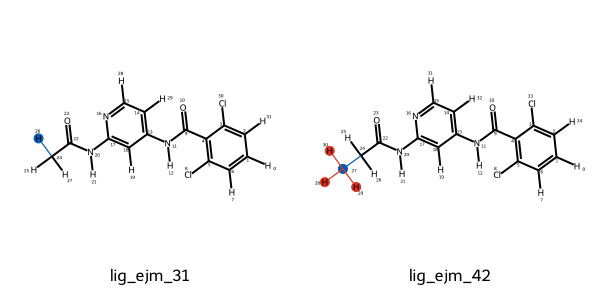

In [6]:
from IPython.display import display, HTML, Image, Markdown, Latex
lomap_mapping

It is also possible to visualize the mapping in 3D using py3dmol:

Here, the visualization_3D method displays the two end state molecules (left and right), in addition to the hybrid molecule (middle).

Atoms that have the same sphere color in both end states are mapped (i.e. will be interpolated between each other), whilst those that do not have a coloured sphere are unmapped (i.e. will be transformed into dummy atoms in the opposite end state).

In [7]:
# Visualize the mapping in 3D
from openfe.utils import visualization_3D

visualization_3D.view_mapping_3d(lomap_mapping, show_atomIDs=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Define Chemical systems = ligand + protein + solvent

`ChemicalSystems` take in:

1. A dictionary of the chemical components (e.g. `SmallMoleculeComponent`,
   `ProteinComponent`, `SolventComponent`) defining the system.

2. An identifier name (optional), for the `ChemicalSystem`. This is used as part
   of the hash identifier of the `ChemicalSystem`, and can help distinguish between
   otherwise comparable systems.


In the case of a relative ligand binding free energy calculation for lig_ejm_31 -> lig_ejm_47, four ChemicalSystems must be defined:

* ligand1 in complex with TYK2 in a box of water
* ligand2 in complex with TYK2 in a box of water
* ligand1 in a box of water
* ligand2 in a box of water

Here we will be passing the previously defined SmallMoleculeComponents for lig_ejm_31 and lig_ejm_47. We will also pass a ProteinComponent generated from the PDB file present under inputs/tyk2_protein.pdb. Finally, instead of passing in a specific box of water, we will define a SolventComponent which will contain the necessary information for OpenMM's Modeller class to add water and 0.15 M NaCl around the solute when creating the OpenMM simulation objects.

In [9]:
# ligands that we will connect by an alchemical transformation for FEP


from openfe import ChemicalSystem

A_complex = ChemicalSystem({'ligand' : ligand_mols[0],
                            'solvent' : solvent,
                            'protein' : protein}, name = 'complex_A')

B_complex = ChemicalSystem({'ligand' : ligand_mols[4],
                            'solvent' : solvent,
                            'protein' : protein}, name = 'complex_B')

A_solvent = ChemicalSystem({'ligand' : ligand_mols[0],
                            'solvent' : solvent
                            }, name = 'solvent_A')

B_solvent = ChemicalSystem({'ligand' : ligand_mols[4],
                            'solvent' : solvent
                            }, name = 'solvent_B')

print(A_complex, B_solvent)

ChemicalSystem(name=complex_A, components={'ligand': SmallMoleculeComponent(name=lig_ejm_31), 'solvent': SolventComponent(name=O, Na+, Cl-), 'protein': ProteinComponent(name=TYK2)}) ChemicalSystem(name=solvent_B, components={'ligand': SmallMoleculeComponent(name=lig_ejm_47), 'solvent': SolventComponent(name=O, Na+, Cl-)})


### Define the Protocol: simulation setup, $\lambda$ schedule, equilibration...

Now that we have a set of atom mappings defined, we know which atoms should
undergo alchemical transformations to capture the free energy cost of
transforming from one ligand to another.

To simulate this transformation, we use the equilibrium RBFE protocol
implemented in OpenFE. This uses OpenMM to run a Perses-like relative
ligand binding free energy calculation using a single topology approach.

To achieve this simulation, the following steps need to happen:

1. Create OpenMM systems of both end states


2. Create a hybrid topology based on these defined end states


3. Set an appropriate $\lambda$ schedule


4. Set a MultiState reporter to write out appropriate coordinates and energies


5. Create an OpenMM sampler (in this case we will be using a replica exchange sampler)


6. Carry out the necessary simulation steps (minimization, equilibration, and production)


The `RelativeHybridTopologyProtocol` class in `openfe.protocols.openmm_rfe`
implements a means to achieve all the above with minimal intervention.

Here we work through its usage for the `ligand1` -> `ligand2` binding free energy
test case. As this involves both a relative binding free energy in solvent
and complex phases, `RelativeHybridTopologyProtocol` will
be used to build two separate `ProtocolDAG` (directed-acyclic-graph) classes, one for each phase.
These `DAG`s (which contain the necessary individual simulations), are then executed to yield
the desired free energy results.

In [10]:
# define protocol

from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
from openff.units import unit

# Create the default settings, print simulation steps
rbfe_settings = RelativeHybridTopologyProtocol.default_settings()
print(rbfe_settings.simulation_settings)

# Create RBFE Protocol class
rbfe_protocol = RelativeHybridTopologyProtocol(
    settings=rbfe_settings
)
print(type(rbfe_protocol))    # openmm protocol for optimization

# This Protocol defines the procedure to estimate a free energy difference between two chemical systems,
# with the details of the two end states yet to be defined.

equilibration_length=<Quantity(1.0, 'nanosecond')> production_length=<Quantity(5.0, 'nanosecond')> minimization_steps=5000 time_per_iteration=<Quantity(1.0, 'picosecond')> real_time_analysis_interval=<Quantity(250.0, 'picosecond')> early_termination_target_error=<Quantity(0.0, 'kilocalorie_per_mole')> real_time_analysis_minimum_time=<Quantity(500.0, 'picosecond')> sampler_method='repex' sams_flatness_criteria='logZ-flatness' sams_gamma0=1.0 n_replicas=11
<class 'openfe.protocols.openmm_rfe.equil_rfe_methods.RelativeHybridTopologyProtocol'>


### Combine `ChemicalSystems`, `mapping`, and `protocol` and define a `Transformation`

A transformation can be dumped into a .json file ('configuration file'), so that it can be run outside of the notebook from the command line, or be farmed out as individual jobs on a HPC cluster. so that they can be run independently using the `openfe quickrun` command.

As previously detailed, we create two sets of transformations for the complex and the solvent legs of the thermodynamic cycle

In [11]:
# transformation definition
from openfe import Transformation
transformation_complex = Transformation(stateA = A_complex, stateB = B_complex,
                                        mapping = lomap_mapping, protocol = rbfe_protocol, name = 'complex_transf')

transformation_solvent = Transformation(stateA = A_solvent, stateB = B_solvent,
                                        mapping = lomap_mapping, protocol = rbfe_protocol, name = 'solvent_transf')

save_ = True

if save_ == True:

    folder = 'LB_tests'
    
    if not os.path.exists(folder):
        os.makedirs(folder)   # creates intermediate dirs if needed
        print(f"Created folder: {folder}")
    else:
        print(f"Folder already exists: {folder}")

    transformation_complex.dump(folder + 'Test_transformationAB_complex.json')
    transformation_solvent.dump(folder + 'Test_transformationAB_solvent.json')

Folder already exists: LB_tests


/Users/lboninsegna/miniforge3/envs/openfe_env/lib/python3.13/site-packages/gufe/transformations/transformation.py:124: DeprecationWarning: use of this method is deprecated; instead use `to_json`
  warnings.warn(
/Users/lboninsegna/miniforge3/envs/openfe_env/lib/python3.13/site-packages/gufe/transformations/transformation.py:124: DeprecationWarning: use of this method is deprecated; instead use `to_json`
  warnings.warn(


To summarize, this `Transformation` contains:
- chemical models of both sides of the alchemical transformation in `stateA` and `stateB`
- the correspondence of items in these two sides in `mapping`
- a description of the exact computational algorithm to use to perform the estimate in `protocol`

### Run transformations: 

With the Transformation defined, we can move onto creating the ProtocolDAG.

The Transformation.create() method creates a directed-acyclic-graph (DAG) of computational tasks necessary for creating an estimate of the free energy difference between the two chemical systems.

The individual pieces of computational work are called Units. In this particular Protocol, the Units defined are three independent repeats of the alchemical transformation



In [ ]:
# from here, Python API or others, save info
from openfe import execute_DAG

complex_dag = transformation_complex.create()
solvent_dag = transformation_solvent.create()

# Finally we can run the simulations...this is a code snippet, simulations have to be run on a HPC
complex_path = pathlib.Path('./complex')
complex_path.mkdir()

# First the complex transformation
complex_dag_results = execute_DAG(complex_dag, scratch_basedir=complex_path, shared_basedir=complex_path)

# Next the solvent state transformation
solvent_path = pathlib.Path('./solvent')
solvent_path.mkdir()

solvent_dag_results = execute_DAG(solvent_dag, scratch_basedir=solvent_path, shared_basedir=solvent_path)


# Analyze the results. 

There is a built in CLI command `openfe gather` to automatically combine all the simulation results and output the $\Delta \Delta G$ estimate with the uncertainty coming from three independent productiion runs. Here, we can just use the `gather()` methods

Results are available for a much larger Alchemical Network, which contains our standard A --> B transformation. So we can procure those results and take it from there.

Standard Multistate Bennett Acceptance Ratio (MBAR) [histogram free improvement over WHAM, which also extends to any type of TD state] is used to pool together and reweigh free energy values from different TD states so to get an unbiased result.

Assume we have:
* $K$ states, each corresponding to a $\lambda_k$ value; so, reduced potentials: $u_k(x) = \beta U_k (x)$
*  $N_k$ is the total number of samples for state, so that $\sum_k N_k = N$
* Configurations $x_n, n = 1,\ldots, N$, pooled from all states
*  looking for the unknown dimensionless free energies $\hat{f}_i$ (defined up to an additive constant).
MBAR self-consistent equations read:

$$\hat{f}_i = -\ln \left[ \sum_{n=1}^N \frac{e^{-u_i(x_n)}}{\sum_k N_k e^{-u_k(x_n) + f_k}}\right]$$

Please note the nested sums over the states and the configurations; Once **free energies** are solved for, then we can reweigh configuration $x_n$ in state $i$

$$W_{ni} = \frac{e^{-u_i(x_n) + \hat{f}_i}}{\sum_k^K N_k e^{-u_k(x_n) + \hat{f}_k}}$$

In RBFE workflows, compute $\Delta G_{ij} = -\frac{1}{\beta} \Delta f_{ij}$ for the alchemical path in the bound leg and the solvent leg, then take the cycle different for the $\Delta \Delta G$

In [12]:
print(transformation_complex)

# Get the complex and solvent results
complex_results = rbfe_protocol.gather([complex_dag_results])
solvent_results = rbfe_protocol.gather([solvent_dag_results])

print(f"Complex dG: {complex_results.get_estimate()}, err {complex_results.get_uncertainty()}")
print(f"Solvent dG: {solvent_results.get_estimate()}, err {solvent_results.get_uncertainty()}")



Transformation(stateA=ChemicalSystem(name=complex_A, components={'ligand': SmallMoleculeComponent(name=lig_ejm_31), 'solvent': SolventComponent(name=O, Na+, Cl-), 'protein': ProteinComponent(name=TYK2)}), stateB=ChemicalSystem(name=complex_B, components={'ligand': SmallMoleculeComponent(name=lig_ejm_47), 'solvent': SolventComponent(name=O, Na+, Cl-), 'protein': ProteinComponent(name=TYK2)}), protocol=<RelativeHybridTopologyProtocol-7b2dbc4359cd0b5bd0fcd8e57567031d>, name=complex_transf)


NameError: name 'complex_dag_results' is not defined